# HITL agent: pause now, resume later

In `main.py` the agent **blocks** on `input()` while it waits for a human. That's fine for a demo,
but in production the reviewer may answer minutes or days later, from a different request
(a web UI, Slack button, email link...).

The production pattern, which this notebook uses:

1. **Start**: run the agent until it hits a risky tool call. The HITL middleware raises an
   *interrupt*, the graph state is saved in the **checkpointer** under the `thread_id`,
   and the call **returns immediately**. Nothing is waiting.
2. **Later**: anyone with the same checkpointer + `thread_id` looks up the pending request
   and resumes with `Command(resume={"decisions": [...]})`.

Each cell below is a separate "request". Run the *start* cells, wait as long as you like
(the `InMemorySaver` lives as long as the kernel), then run the *resume* cells.

> ⚠️ **Restarting the kernel wipes `InMemorySaver`** and all paused runs. For waits that need to
> survive restarts or deploys, swap in a persistent saver (see the last section).

## 1. Setup

In [1]:
import contextlib
import json
import os
import re
import sys
import uuid
from datetime import datetime, timezone
from pathlib import Path

from dotenv import load_dotenv

# find src/ (the folder containing the hitl_agent package) wherever the notebook runs from
_here = Path.cwd().resolve()
SRC = next(c for p in [_here, *_here.parents] for c in (p, p / "src")
           if (c / "hitl_agent" / "agent.py").exists())
sys.path.insert(0, str(SRC))
load_dotenv(SRC / "hitl_agent" / ".env")

from langchain_core.language_models import BaseChatModel
from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.outputs import ChatGeneration, ChatResult
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

from hitl_agent.agent import build_agent, get_langfuse_handler
from hitl_agent.tools import OUTBOX

print("hitl_agent package:", SRC / "hitl_agent")

hitl_agent package: /Users/ankit/Library/CloudStorage/OneDrive-Personal/work/EdYoda/genai_agentic_ai/src/hitl_agent


## 2. Config

`USE_OFFLINE_MODEL = True` swaps the LLM for a small rule-based model that emits tool calls
from your text. The **real** agent graph, HITL middleware, checkpointer and tools still run,
so you can test pause/resume **without any LLM calls or credits**.

The offline model understands:
- an email address in the text → `send_email` to each address (several addresses = several calls paused together)
- an arithmetic expression like `2340 * 0.175` → `calculate`

In [ ]:
USE_OFFLINE_MODEL = True              # True -> no LLM calls, no credits
MODEL_SPEC = "openai:gpt-4.1-mini"    # used only when USE_OFFLINE_MODEL = False
USE_LANGFUSE = False                  # trace start/resume requests to Langfuse (same session per thread)

In [44]:
class OfflineModel(BaseChatModel):
    """Rule-based stand-in for an LLM: zero API calls, zero credits."""

    @property
    def _llm_type(self) -> str:
        return "offline-rules"

    def bind_tools(self, tools, **kwargs):
        return self

    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        last = messages[-1]
        if isinstance(last, ToolMessage):  # tools ran (or were rejected) -> wrap up
            results = []
            for m in reversed(messages):
                if not isinstance(m, ToolMessage):
                    break
                results.append(f"{m.name}: {str(m.content).strip().splitlines()[-1]}")
            reply = AIMessage(content="Done. " + " | ".join(reversed(results)))
        else:
            text = str(last.content)
            emails = re.findall(r"[\w.+-]+@[\w-]+\.[\w.]+", text)
            expr = re.search(r"[\d(][\d\s.()]*[-+*/][\d\s.+\-*/()]*[\d)]",
                             re.sub(r"[\w.+-]+@[\w-]+\.[\w.]+", "", text))
            calls = [{"name": "send_email", "id": f"call_{uuid.uuid4().hex[:8]}",
                      "args": {"to": to, "subject": "Update", "body": text}} for to in emails]
            if expr:
                calls.append({"name": "calculate", "id": f"call_{uuid.uuid4().hex[:8]}",
                              "args": {"expression": expr.group().strip()}})
            reply = AIMessage(content="", tool_calls=calls) if calls else AIMessage(
                content="(offline model) try: 'email ops@example.com the report' "
                        "or 'calculate 2340 * 0.175'")
        return ChatResult(generations=[ChatGeneration(message=reply)])

## 3. Checkpointer + agent

The checkpointer is created **once** (re-running this cell keeps it). The agent is just code,
so you can rebuild it at any time, even between pause and resume, just as a production
deploy would, and the paused runs are still resumable because the state lives in the checkpointer.

In [45]:
if "checkpointer" not in globals():   # keep paused runs across re-runs of this cell
    checkpointer = InMemorySaver()

handler = get_langfuse_handler() if USE_LANGFUSE else None
if USE_OFFLINE_MODEL:
    agent = build_agent(model=OfflineModel(), checkpointer=checkpointer)
else:
    os.environ["LLM_MODEL"] = MODEL_SPEC
    agent = build_agent(checkpointer=checkpointer)

print("model:", "offline (no LLM calls)" if USE_OFFLINE_MODEL else MODEL_SPEC,
      "| langfuse:", "on" if handler else "off")

model: offline (no LLM calls) | langfuse: on


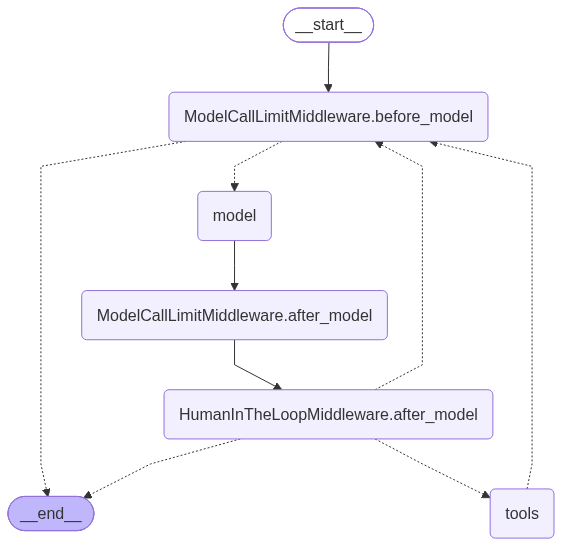

In [46]:
agent

In [47]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage, SystemMessage

def print_messages(messages: list[BaseMessage]):
    """Pretty-prints a list of LangChain messages with clear labels and colors."""
    
    # ANSI escape codes for basic terminal colors
    COLOR_SYSTEM = "\033[95m"  # Magenta
    COLOR_HUMAN = "\033[92m"   # Green
    COLOR_AI = "\033[94m"      # Blue
    COLOR_TOOL = "\033[93m"    # Yellow
    COLOR_RESET = "\033[0m"    # Reset to default
    BOLD = "\033[1m"

    for idx, msg in enumerate(messages, 1):
        # 1. Determine the message type, sender name, and color
        if isinstance(msg, SystemMessage):
            role = "SYSTEM"
            color = COLOR_SYSTEM
        elif isinstance(msg, HumanMessage):
            role = msg.name.upper() if getattr(msg, "name", None) else "HUMAN"
            color = COLOR_HUMAN
        elif isinstance(msg, AIMessage):
            role = msg.name.upper() if getattr(msg, "name", None) else "AI"
            color = COLOR_AI
        elif isinstance(msg, ToolMessage):
            role = f"TOOL [{msg.name}]"
            color = COLOR_TOOL
        else:
            role = msg.__class__.__name__.replace("Message", "").upper()
            color = COLOR_RESET

        # 2. Print the Header Block
        print(f"\n{color}{BOLD}=== [{idx}] {role} ==={COLOR_RESET}")

        # 3. Print Tool Calls if the AI is invoking a tool
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tool_call in msg.tool_calls:
                print(f"{COLOR_TOOL}🔧 Tool Call: {tool_call['name']}{COLOR_RESET}")
                print(f"   Arguments: {tool_call['args']}")

        # 4. Print the Main Content (if it exists)
        if msg.content:
            # Ensure text wraps or indents cleanly if it spans multiple lines
            content_str = str(msg.content).strip()
            print(content_str)
            
    print("\n" + "=" * 30)


## 4. Helpers: `start`, `resume`, `paused_threads`

These are what your API endpoints would be in production: `POST /chat` → `start()`,
`GET /reviews` → `paused_threads()`, `POST /reviews/{thread_id}` → `resume()`.

In [48]:
def cfg(thread_id):
    return {"configurable": {"thread_id": thread_id},
            "callbacks": [handler] if handler else []}


@contextlib.contextmanager
def trace(name, thread_id, input):
    """One Langfuse trace per request; start + resume share the session (= thread_id)."""
    if not handler:
        yield None
        return
    from langfuse import get_client, propagate_attributes
    lf = get_client()
    with propagate_attributes(session_id=thread_id, trace_name=name, tags=["hitl-notebook"]):
        with lf.start_as_current_observation(name=name, as_type="agent", input=input) as span:
            yield span
    lf.flush()


def _ago(iso):
    secs = int((datetime.now(timezone.utc) - datetime.fromisoformat(iso)).total_seconds())
    return f"{secs // 3600}h {secs % 3600 // 60}m {secs % 60}s" if secs >= 3600 else \
           f"{secs // 60}m {secs % 60}s"


def pending(thread_id):
    """The paused HITL request for this thread, or None if it isn't waiting."""
    state = agent.get_state(cfg(thread_id))
    return state.interrupts[0].value if state.interrupts else None


def show(thread_id):
    """Print the pending review, or the agent's last answer."""
    state = agent.get_state(cfg(thread_id))
    if state.interrupts:
        req = state.interrupts[0].value
        allowed = {rc["action_name"]: rc["allowed_decisions"] for rc in req["review_configs"]}
        print(f"⏸  {thread_id} is PAUSED (waiting {_ago(state.created_at)}); "
              f"{len(req['action_requests'])} call(s) to review:")
        for i, a in enumerate(req["action_requests"]):
            print(f"  [{i}] {a['name']}({json.dumps(a['args'], ensure_ascii=False)})"
                  f"   allowed: {allowed[a['name']]}")
        return "paused"
    msgs = state.values.get("messages", [])
    answer = msgs[-1].content if msgs else ""
    if isinstance(answer, list):
        answer = "".join(b.get("text", "") for b in answer if isinstance(b, dict))
    print(f"✅ {thread_id} finished → {answer}")
    return answer


def start(text, thread_id=None):
    """Send a user message. Returns as soon as the agent finishes OR pauses; never blocks."""
    thread_id = thread_id or f"nb-{uuid.uuid4().hex[:6]}"
    if pending(thread_id):
        raise RuntimeError(f"{thread_id} is waiting for a review; resume() it first")
    with trace("hitl-start", thread_id, text) as span:
        agent.invoke({"messages": [{"role": "user", "content": text}]}, cfg(thread_id))
        out = show(thread_id)
        if span:
            span.update(output=out)
    return thread_id


# decision builders: one per paused call, in the order shown by show()
def approve():
    return {"type": "approve"}

def reject(reason=None):
    return {"type": "reject", **({"message": reason} if reason else {})}

def edit(**changes):
    """Only pass the args you want to change, e.g. edit(to="ops@example.com")."""
    return {"type": "edit", "changes": changes}


def resume(thread_id, *decisions):
    """Deliver the human's decisions (possibly hours later) and let the agent continue."""
    req = pending(thread_id)
    if req is None:
        print(f"{thread_id} is not paused, nothing to resume")
        return show(thread_id)
    actions = req["action_requests"]
    if len(decisions) != len(actions):
        raise ValueError(f"{len(actions)} paused call(s) need {len(actions)} decision(s), "
                         f"got {len(decisions)}")
    allowed = {rc["action_name"]: rc["allowed_decisions"] for rc in req["review_configs"]}
    final = []
    for a, d in zip(actions, decisions):
        if d["type"] not in allowed[a["name"]]:
            raise ValueError(f"{d['type']!r} not allowed for {a['name']} (allowed: {allowed[a['name']]})")
        if d["type"] == "edit":
            d = {"type": "edit", "edited_action": {"name": a["name"],
                                                   "args": {**a["args"], **d["changes"]}}}
        final.append(d)

    with trace("hitl-resume", thread_id, {"decisions": final}) as span:
        if span:  # record each human decision as an event + a categorical score
            from langfuse import get_client
            lf = get_client()
            for a, d in zip(actions, final):
                lf.create_event(name=f"human-review:{a['name']}",
                                input={"tool": a["name"], "args": a["args"]}, output=d)
                lf.score_current_trace(name=f"hitl_{a['name']}", value=d["type"],
                                       data_type="CATEGORICAL", comment=d.get("message"))
        agent.invoke(Command(resume={"decisions": final}), cfg(thread_id))
        out = show(thread_id)  # may be paused AGAIN if the agent made another risky call
        if span:
            span.update(output=out)
    return out


def paused_threads():
    """Every thread in the checkpointer that is waiting for a human, like a review inbox."""
    threads = sorted({c.config["configurable"]["thread_id"] for c in checkpointer.list(None)})
    waiting = [t for t in threads if pending(t)]
    print(f"{len(waiting)} paused / {len(threads)} thread(s)")
    for t in waiting:
        show(t)
    return waiting


def sent_emails():
    """What send_email actually wrote to the outbox, proving nothing ran before approval."""
    return [json.loads(l) for l in OUTBOX.read_text().splitlines()] if OUTBOX.exists() else []

## 5. Start some runs (they pause and return immediately)

In [49]:
output = agent.invoke({"messages": [{'role': "user", "content": "hi, what is the weather in bangalore?"}]}, config={"configurable": {"thread_id": 'random_id_here2'}}) 

In [50]:
print_messages(output["messages"])


=== [1] HUMAN ===
hi, what is the weather in delhi

=== [2] HITL-DEMO-AGENT ===
🔧 Tool Call: get_weather
   Arguments: {'city': 'Delhi'}

=== [3] TOOL [get_weather] ===
Delhi, India: clear sky, 27.5°C, humidity 63%, wind 7.2 km/h

=== [4] HITL-DEMO-AGENT ===
The current weather in Delhi is clear sky with a temperature of 27.5°C, humidity at 63%, and wind speed of 7.2 km/h.

=== [5] HUMAN ===
hi, what is the weather in bangalore?

=== [6] HITL-DEMO-AGENT ===
🔧 Tool Call: get_weather
   Arguments: {'city': 'Bangalore'}

=== [7] TOOL [get_weather] ===
Bangalore Town, Pakistan: partly cloudy, 30.7°C, humidity 63%, wind 16.8 km/h

=== [8] HITL-DEMO-AGENT ===
The current weather in Bangalore is partly cloudy with a temperature of 30.7°C, humidity at 63%, and wind speed of 16.8 km/h.

=== [9] HUMAN ===
hi, what is the weather in bangalore?

=== [10] HITL-DEMO-AGENT ===
(offline model) try: 'email ops@example.com the report' or 'calculate 2340 * 0.175'



In [51]:
t1 = start("email the quarterly report to ceo@example.com")

Langfuse was not able to parse the LLM model. The LLM call will be recorded without model name. Please create an issue: https://github.com/langfuse/langfuse/issues/new/choose


⏸  nb-e54149 is PAUSED (waiting 0m 0s); 1 call(s) to review:
  [0] send_email({"to": "ceo@example.com", "subject": "Update", "body": "email the quarterly report to ceo@example.com"})   allowed: ['approve', 'edit', 'reject']


In [52]:
t2 = start("calculate 2340 * 0.175")

⏸  nb-335130 is PAUSED (waiting 0m 0s); 1 call(s) to review:
  [0] calculate({"expression": "2340 * 0.175"})   allowed: ['approve', 'reject']


In [53]:
# two risky calls in one step -> both paused together, one decision each
t3 = start("send the release notes to dev@example.com and to all@example.com")

⏸  nb-5a292c is PAUSED (waiting 0m 0s); 2 call(s) to review:
  [0] send_email({"to": "dev@example.com", "subject": "Update", "body": "send the release notes to dev@example.com and to all@example.com"})   allowed: ['approve', 'edit', 'reject']
  [1] send_email({"to": "all@example.com", "subject": "Update", "body": "send the release notes to dev@example.com and to all@example.com"})   allowed: ['approve', 'edit', 'reject']


In [54]:
print("emails actually sent so far:", sent_emails())   # nothing has run yet

emails actually sent so far: []


## ⏳ Walk away

Nothing is running or blocked now. The paused state is sitting in the checkpointer.
Come back in 10 minutes or tomorrow (just keep the kernel alive) and continue below.

This is the "reviewer inbox" a UI would show:

In [55]:
paused_threads();

4 paused / 10 thread(s)
⏸  nb-335130 is PAUSED (waiting 0m 16s); 1 call(s) to review:
  [0] calculate({"expression": "2340 * 0.175"})   allowed: ['approve', 'reject']
⏸  nb-5a292c is PAUSED (waiting 0m 14s); 2 call(s) to review:
  [0] send_email({"to": "dev@example.com", "subject": "Update", "body": "send the release notes to dev@example.com and to all@example.com"})   allowed: ['approve', 'edit', 'reject']
  [1] send_email({"to": "all@example.com", "subject": "Update", "body": "send the release notes to dev@example.com and to all@example.com"})   allowed: ['approve', 'edit', 'reject']
⏸  nb-e54149 is PAUSED (waiting 0m 24s); 1 call(s) to review:
  [0] send_email({"to": "ceo@example.com", "subject": "Update", "body": "email the quarterly report to ceo@example.com"})   allowed: ['approve', 'edit', 'reject']
⏸  nb-faf7af is PAUSED (waiting 4m 37s); 1 call(s) to review:
  [0] calculate({"expression": "2340 * 0.175"})   allowed: ['approve', 'reject']


## 6. Resume later with the human's decisions

In [56]:
# edit only the recipient; subject/body are kept
resume(t1, edit(to="ops@example.com"))

✅ nb-e54149 finished → Done. send_email: Email sent to ops@example.com with subject 'Update'.


"Done. send_email: Email sent to ops@example.com with subject 'Update'."

In [57]:
resume(t2, approve())

✅ nb-335130 finished → Done. calculate: 2340 * 0.175 = 409.5


'Done. calculate: 2340 * 0.175 = 409.5'

In [58]:
# one decision per paused call, in the order shown: approve the first, reject the second
resume(t3, approve(), reject("Don't email the whole company"))

✅ nb-5a292c finished → Done. send_email: User rejected the tool call for `send_email` with reason: Don't email the whole company | send_email: Email sent to dev@example.com with subject 'Update'.


"Done. send_email: User rejected the tool call for `send_email` with reason: Don't email the whole company | send_email: Email sent to dev@example.com with subject 'Update'."

In [61]:
print(json.dumps(sent_emails(), indent=2))

print("\n\n\nlist of paused thread below:")
paused_threads();

[
  {
    "sent_at": "2026-09-27T16:00:33",
    "to": "ops@example.com",
    "subject": "Update",
    "body": "email the quarterly report to ceo@example.com"
  },
  {
    "sent_at": "2026-09-27T16:00:43",
    "to": "dev@example.com",
    "subject": "Update",
    "body": "send the release notes to dev@example.com and to all@example.com"
  }
]



list of paused thread below:
1 paused / 10 thread(s)
⏸  nb-faf7af is PAUSED (waiting 5m 21s); 1 call(s) to review:
  [0] calculate({"expression": "2340 * 0.175"})   allowed: ['approve', 'reject']


## 7. The conversation continues on the same thread

After the resume, the thread is a normal conversation again: the next message has full history.

In [62]:
start("also send it to cfo@example.com", thread_id=t1)

⏸  nb-e54149 is PAUSED (waiting 0m 0s); 1 call(s) to review:
  [0] send_email({"to": "cfo@example.com", "subject": "Update", "body": "also send it to cfo@example.com"})   allowed: ['approve', 'edit', 'reject']


'nb-e54149'

In [63]:
resume(t1, reject("CFO already has it"))

✅ nb-e54149 finished → Done. send_email: User rejected the tool call for `send_email` with reason: CFO already has it


'Done. send_email: User rejected the tool call for `send_email` with reason: CFO already has it'

## 8. Look inside the checkpointer

Every step is a checkpoint with a timestamp. The gap between the checkpoint where the run
paused and the next one is how long the human took.

In [66]:
def timeline(thread_id):
    for s in reversed(list(agent.get_state_history(cfg(thread_id)))):
        paused = " ⏸ PAUSED here" if s.interrupts else ""
        print(f"{s.created_at[11:19]}  step={s.metadata.get('step'):>2}  "
              f"next={list(s.next) or '-'}{paused}")

timeline(t1)

10:30:06  step=-1  next=['__start__']
10:30:06  step= 0  next=['ModelCallLimitMiddleware.before_model']
10:30:06  step= 1  next=['model']
10:30:06  step= 2  next=['ModelCallLimitMiddleware.after_model']
10:30:06  step= 3  next=['HumanInTheLoopMiddleware.after_model'] ⏸ PAUSED here
10:30:33  step= 4  next=['tools']
10:30:33  step= 5  next=['ModelCallLimitMiddleware.before_model']
10:30:33  step= 6  next=['model']
10:30:33  step= 7  next=['ModelCallLimitMiddleware.after_model']
10:30:33  step= 8  next=['HumanInTheLoopMiddleware.after_model']
10:30:33  step= 9  next=-
10:31:35  step=10  next=['__start__']
10:31:35  step=11  next=['ModelCallLimitMiddleware.before_model']
10:31:35  step=12  next=['model']
10:31:35  step=13  next=['ModelCallLimitMiddleware.after_model']
10:31:35  step=14  next=['HumanInTheLoopMiddleware.after_model'] ⏸ PAUSED here
10:31:36  step=15  next=['ModelCallLimitMiddleware.before_model']
10:31:36  step=16  next=['model']
10:31:36  step=17  next=['ModelCallLimitMiddle

## 9. Edge cases worth trying

- **Resume twice**: `resume(t2, approve())` again prints "not paused"; it doesn't re-run anything.
- **Wrong number of decisions**: `resume(t3, approve())` while two calls are pending raises.
- **Decision not allowed**: `edit(...)` on `calculate` raises (policy allows approve/reject only).
- **New message on a paused thread**: `start("hi", thread_id=<paused>)` raises; resolve the review first.
- **Rebuild the agent mid-pause**: start a run, re-run the section 3 cell (e.g. switch
  `USE_OFFLINE_MODEL = False`), then resume. The paused state lives in the checkpointer,
  not in the agent object.

## 10. Surviving kernel restarts / multiple processes

`InMemorySaver` only lives inside this kernel. For real long waits, use a persistent saver;
nothing else in this notebook changes:

```python
# uv add langgraph-checkpoint-sqlite
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
checkpointer = SqliteSaver(sqlite3.connect("hitl_checkpoints.db", check_same_thread=False))
# production / multiple workers: langgraph-checkpoint-postgres -> PostgresSaver
```

With that, you can start a run, **restart the kernel**, rebuild the agent, and `resume(thread_id, ...)`
still works as long as you know the `thread_id` (store it with your review ticket).